<a href="https://colab.research.google.com/github/NikhilaVecham/Plants-Seedling-Classification---Computer-Vision/blob/main/CV_Project_Full_Code_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Computer Vision: Plant Seedlings Classification

## Problem Statement

### Context

In recent times, the field of agriculture has been in urgent need of modernizing, since the amount of manual work people need to put in to check if plants are growing correctly is still highly extensive. Despite several advances in agricultural technology, people working in the agricultural industry still need to have the ability to sort and recognize different plants and weeds, which takes a lot of time and effort in the long term. The potential is ripe for this trillion-dollar industry to be greatly impacted by technological innovations that cut down on the requirement for manual labor, and this is where Artificial Intelligence can actually benefit the workers in this field, as **the time and energy required to identify plant seedlings will be greatly shortened by the use of AI and Deep Learning.** The ability to do so far more efficiently and even more effectively than experienced manual labor, could lead to better crop yields, the freeing up of human inolvement for higher-order agricultural decision making, and in the long term will result in more sustainable environmental practices in agriculture as well.


### Objective

The aim of this project is to Build a Convolutional Neural Netowrk to classify plant seedlings into their respective categories.

### Data Dictionary

The Aarhus University Signal Processing group, in collaboration with the University of Southern Denmark, has recently released a dataset containing **images of unique plants belonging to 12 different species.**

- The dataset can be download from Olympus.
- The data file names are:
    - images.npy
    - Labels.csv
- Due to the large volume of data, the images were converted to the images.npy file and the labels are also put into Labels.csv, so that you can work on the data/project seamlessly without having to worry about the high data volume.

- The goal of the project is to create a classifier capable of determining a plant's species from an image.

**List of Species**

- Black-grass
- Charlock
- Cleavers
- Common Chickweed
- Common Wheat
- Fat Hen
- Loose Silky-bent
- Maize
- Scentless Mayweed
- Shepherds Purse
- Small-flowered Cranesbill
- Sugar beet

### **Note: Please use GPU runtime on Google Colab to execute the code faster.**

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install -q \
tensorflow==2.20.0 \
numpy==2.0.2 \
pandas==2.2.2 \
scikit-learn==1.6.1 \
matplotlib==3.10.0 \
seaborn==0.13.2 \
opencv-python==4.11.0.86

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 2.2.2 which is incompatible.


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
import os
import numpy as np  # Importing numpy for Matrix Operations
import pandas as pd  # Importing pandas to read CSV files
import matplotlib.pyplot as plt # Importting matplotlib for Plotting and visualizing images
import math # Importing math module to perform mathematical operations
import cv2 # Importing openCV for image processing
import seaborn as sns # Importing seaborn to plot graphs

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix                                                     # Importing confusion_matrix to plot the confusion matrix
from sklearn.preprocessing import LabelBinarizer
# Display images using OpenCV
from google.colab.patches import cv2_imshow                                                      # Importing cv2_imshow from google.patches to display images
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend # Import backend here
from keras.callbacks import ReduceLROnPlateau
import random

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(42)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount("/content/drive",force_remount=True)

Mounted at /content/drive


In [ ]:
# Load the image file of dataset
images = np.load('/content/drive/My Drive/images_plant.npy')

# Load the labels file of dataset
labels = pd.read_csv('/content/drive/My Drive/Labels.csv'
)

## Data Overview

### Understand the shape of the dataset

In [ ]:
print(images.shape)
print(labels.shape)

(4750, 128, 128, 3)
(4750, 1)


There are 4750 images of shape 128x128x3, each image having 3 channels

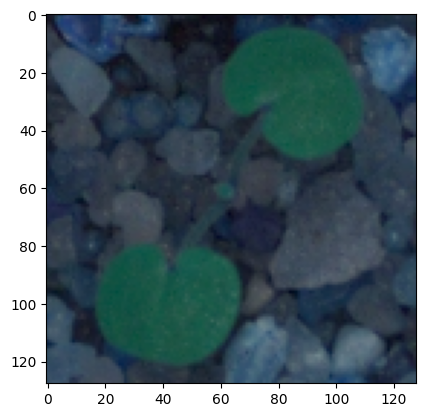

In [ ]:
plt.imshow(images[5]);

## Exploratory Data Analysis

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you understand the data better.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

1. How are these different category plant images different from each other?
2. Is the dataset provided an imbalance? (Check with using bar plots)

### Plotting random images from each of the class

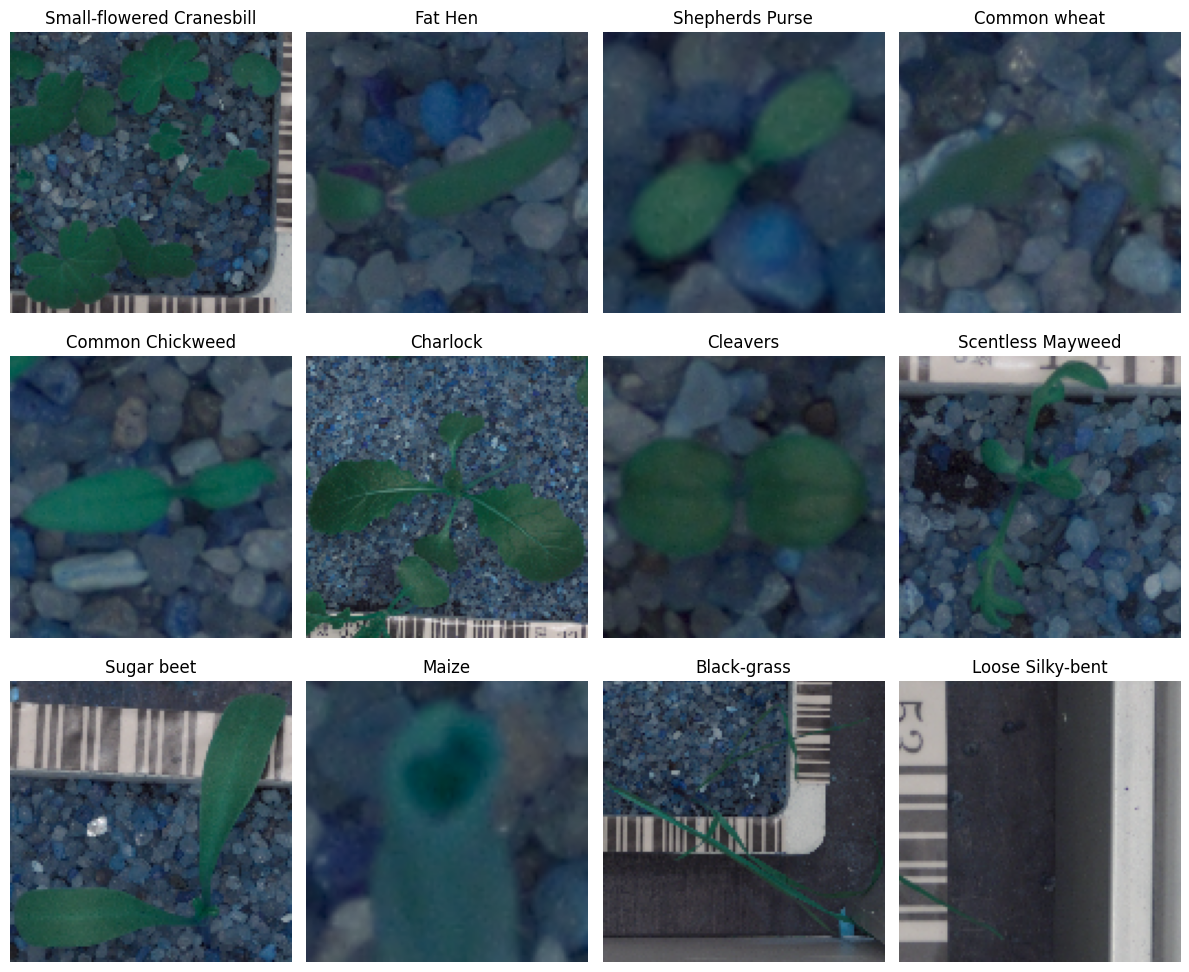

In [ ]:
# Plot one random image from each plant species
classes = labels['Label'].unique()

plt.figure(figsize=(12, 10))

for i, class_name in enumerate(classes):

    # Get indices belonging to the current class
    class_indices = labels.index[labels['Label'] == class_name].tolist()

    # Select one random image from this class
    random_index = np.random.choice(class_indices)

    plt.subplot(3, 4, i + 1)
    plt.imshow(images[random_index])
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Observations:

*   **Variety in Appearance**: The images show significant variation in leaf shape, size, and growth patterns among different species. For example, 'Common Chickweed' appears to have small, round leaves, while 'Maize' and 'Loose Silky-bent' have longer, grass-like leaves.
*   **Background Noise**: The images contain varying backgrounds, often with soil, gravel, or other elements, which could make it challenging for the model to isolate the plant seedling.
*   **Lighting Conditions**: There appear to be differences in lighting across images, which might affect color consistency and shadow presence.
*   **Scale and Orientation**: The seedlings are captured at different scales and orientations, requiring the model to be robust to these transformations.
*   **Visual Similarities**: Some species, particularly those with narrow leaves (e.g., 'Maize', 'Loose Silky-bent', 'Common wheat'), might appear visually similar, potentially leading to misclassifications. Similarly, some broad-leafed plants (e.g., 'Small-flowered Cranesbill', 'Fat Hen') share some visual characteristics.

### Checking the distribution of the target variable

In [ ]:
print(labels['Label'].value_counts())

Label
Loose Silky-bent             654
Common Chickweed             611
Scentless Mayweed            516
Small-flowered Cranesbill    496
Fat Hen                      475
Charlock                     390
Sugar beet                   385
Cleavers                     287
Black-grass                  263
Shepherds Purse              231
Common wheat                 221
Maize                        221
Name: count, dtype: int64


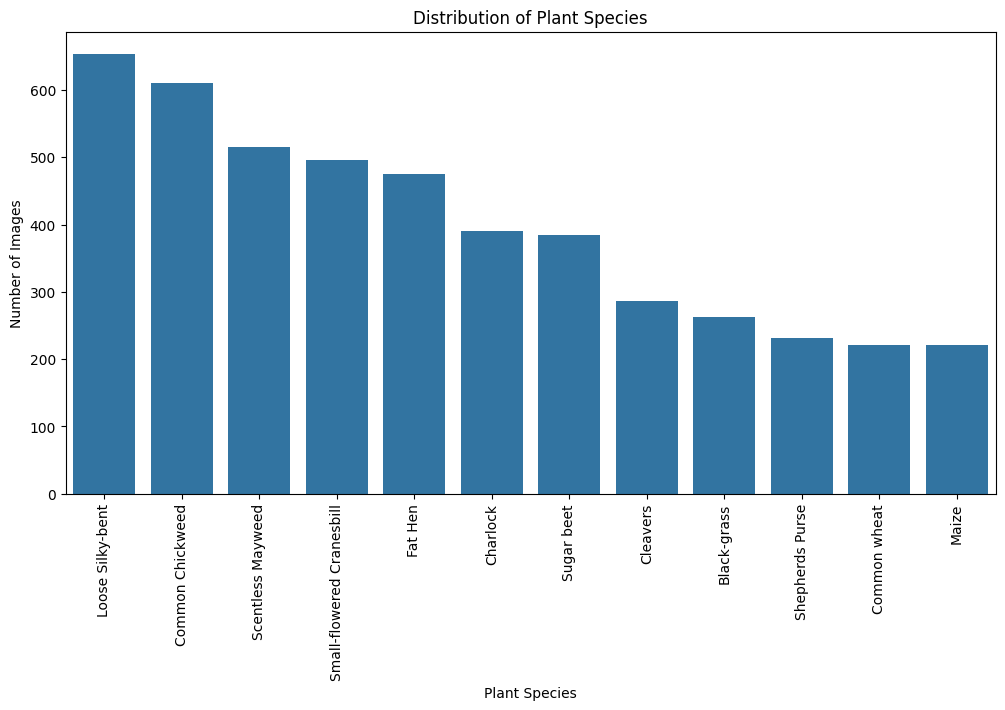

In [ ]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=labels,
    x='Label',
    order=labels['Label'].value_counts().index
)

plt.xticks(rotation=90)
plt.xlabel('Plant Species')
plt.ylabel('Number of Images')
plt.title('Distribution of Plant Species')
plt.show()

### Observations:

- The dataset contains images belonging to **12 different plant species**.
- The distribution of images across the different classes is **not uniform**, indicating some degree of class imbalance.
- **Loose Silky-bent** has the highest number of images, with more than **600 samples**, followed by **Common Chickweed**.
- Because Loose Silky-bent has almost three times as many samples as Common wheat and Maize, the model may become biased toward the more frequent classes. Per-class recall should therefore be examined in addition to overall accuracy.
- Therefore, the dataset can be considered **moderately imbalanced**.

## Data Pre-Processing

### Convert the BGR images to RGB images.

In [ ]:
# Converting the images from BGR to RGB using cvtColor function of OpenCV
for i in range(len(images)):
  images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

### Resize the images

As the size of the images is large, it may be computationally expensive to train on these larger images; therefore, it is preferable to reduce the image size from 128 to 64.

In [ ]:
images_decreased = []
height = 64
width = 64
dimensions = (width, height)
for i in range(len(images)):
  images_decreased.append(cv2.resize(images[i], dimensions, interpolation=cv2.INTER_LINEAR))

**Image before resizing**

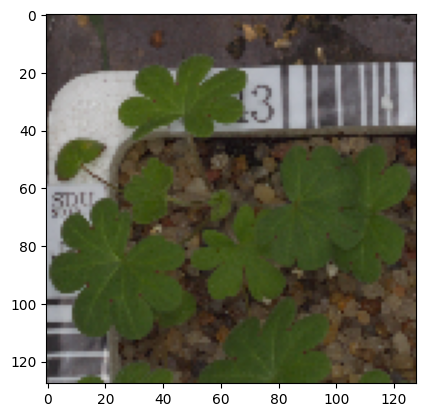

In [ ]:
plt.imshow(images[3]);

**Image after resizing**

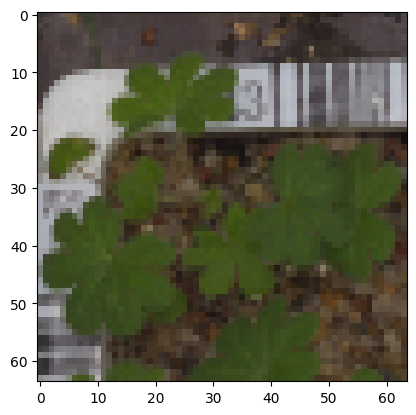

In [ ]:
plt.imshow(images_decreased[3]);

### Data Preparation for Modeling

- Before you proceed to build a model, you need to split the data into train, test, and validation to be able to evaluate the model that you build on the train data
- You'll have to encode categorical features and scale the pixel values.
- You will build a model using the train data and then check its performance

**Split the dataset**

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images_decreased),labels , test_size=0.2, random_state=42,stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [ ]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(3800, 64, 64, 3) (3800, 1)
(475, 64, 64, 3) (475, 1)
(475, 64, 64, 3) (475, 1)


### Encode the target labels

* Convert labels from names to one hot vectors

In [ ]:
# Convert labels from names to one hot vectors.
# We have already used encoding methods like onehotencoder and labelencoder earlier so now we will be using a new encoding method called labelBinarizer.
# Labelbinarizer works similar to onehotencoder

from sklearn.preprocessing import LabelBinarizer
enc = LabelBinarizer()
y_train_encoded = enc.fit_transform(y_train)
y_val_encoded=enc.transform(y_val)
y_test_encoded=enc.transform(y_test)

In [ ]:
# to check the shape of train, validation and test data
y_train_encoded.shape,y_val_encoded.shape,y_test_encoded.shape

((3800, 12), (475, 12), (475, 12))

### Data Normalization

Since the **image pixel values range from 0-255**, our method of normalization here will be **scaling** - we shall **divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [ ]:
# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

### Utility Functions

In [ ]:
# Defining a function to compute different metrics to evaluate classification model performance
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    pred = model.predict(predictors).argmax(axis=1)

    target = target.argmax(axis=1)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model, predictors, target):

    pred = model.predict(predictors).argmax(axis=1)
    target = target.argmax(axis=1)

    cm = tf.math.confusion_matrix(target, pred)

    f, ax = plt.subplots(figsize=(12, 12))

    sns.heatmap(
        cm,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )

    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')
    ax.set_title('Confusion Matrix')

    ax.set_xticklabels(enc.classes_, rotation=45)
    ax.set_yticklabels(enc.classes_, rotation=0)

    plt.show()

## Model Building

In [ ]:
# Clearing backend
backend.clear_session()

In [ ]:
# Fixing the seed for random number generators
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Initializing a sequential model
model1 = Sequential()

# First convolution layer with 128 filters and 3x3 kernel
model1.add(Conv2D(128, (3, 3), activation='relu',
                  padding='same', input_shape=(64, 64, 3)))

# Max pooling layer
model1.add(MaxPooling2D((2, 2), padding='same'))

# Second convolution and max-pooling layers
model1.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model1.add(MaxPooling2D((2, 2), padding='same'))

# Third convolution and max-pooling layers
model1.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model1.add(MaxPooling2D((2, 2), padding='same'))

# Flatten convolution output
model1.add(Flatten())

# Fully connected dense layer with 16 neurons
model1.add(Dense(16, activation='relu'))

# Dropout to reduce overfitting
model1.add(Dropout(0.3))

# Output layer - 12 classes
model1.add(Dense(12, activation='softmax'))

# Adam optimizer
opt = Adam()

# Compile the model
model1.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        32,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,828 (503.23 KB)

 Trainable params: 128,828 (503.23 KB)

 Non-trainable params: 0 (0.00 B)

<b> Fitting the model on the train data

In [ ]:
history_1 = model1.fit(
            X_train_normalized, y_train_encoded,
            epochs=30,
            validation_data=(X_val_normalized,y_val_encoded),
            batch_size=32,
            verbose=2
)

Epoch 1/30
119/119 - 8s - 69ms/step - accuracy: 0.1403 - loss: 2.4382 - val_accuracy: 0.2653 - val_loss: 2.2509
Epoch 2/30
119/119 - 1s - 12ms/step - accuracy: 0.2632 - loss: 2.1569 - val_accuracy: 0.3453 - val_loss: 1.9152
Epoch 3/30
119/119 - 1s - 12ms/step - accuracy: 0.3089 - loss: 1.9455 - val_accuracy: 0.3663 - val_loss: 1.6691
Epoch 4/30
119/119 - 1s - 12ms/step - accuracy: 0.3213 - loss: 1.8390 - val_accuracy: 0.4232 - val_loss: 1.5948
Epoch 5/30
119/119 - 1s - 12ms/step - accuracy: 0.3345 - loss: 1.8266 - val_accuracy: 0.4400 - val_loss: 1.5068
Epoch 6/30
119/119 - 1s - 12ms/step - accuracy: 0.3645 - loss: 1.7063 - val_accuracy: 0.4926 - val_loss: 1.4998
Epoch 7/30
119/119 - 1s - 12ms/step - accuracy: 0.3889 - loss: 1.6531 - val_accuracy: 0.5368 - val_loss: 1.3999
Epoch 8/30
119/119 - 1s - 12ms/step - accuracy: 0.4266 - loss: 1.5611 - val_accuracy: 0.5558 - val_loss: 1.3076
Epoch 9/30
119/119 - 3s - 25ms/step - accuracy: 0.4479 - loss: 1.5236 - val_accuracy: 0.5558 - val_loss:

### **Model Evaluation**

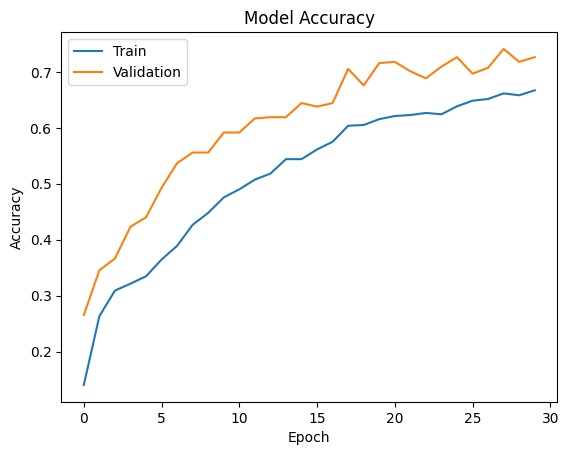

In [ ]:
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_1_train_perf = model_performance_classification(model1, X_train_normalized,y_train_encoded)

print("Train performance metrics")
print(model_1_train_perf)

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.801579  0.801579   0.761269  0.769829


119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


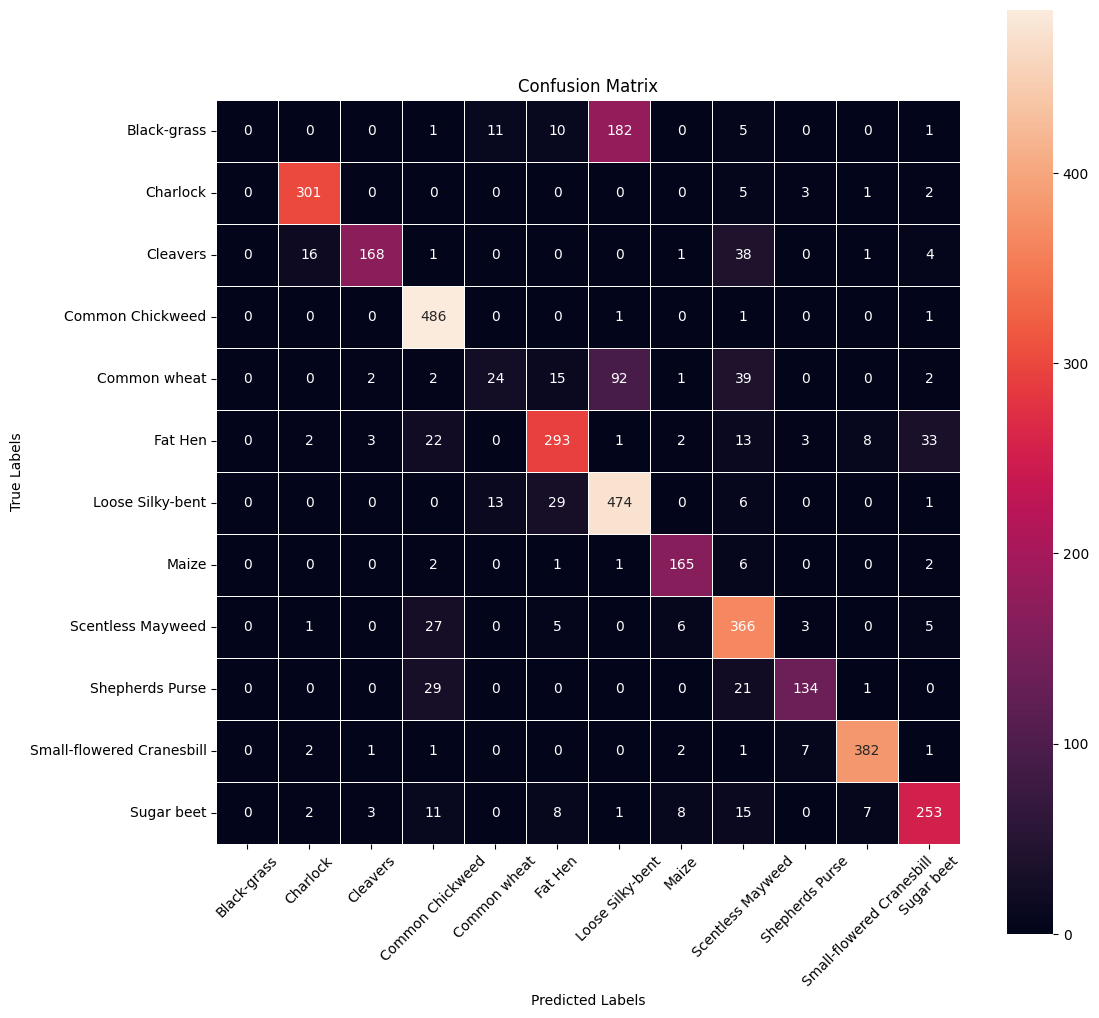

In [ ]:
plot_confusion_matrix(model1,X_train_normalized,y_train_encoded)

In [ ]:
model_1_valid_perf = model_performance_classification(model1, X_val_normalized,y_val_encoded)

print("Validation performance metrics")
print(model_1_valid_perf)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.726316  0.726316   0.696936  0.698574


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


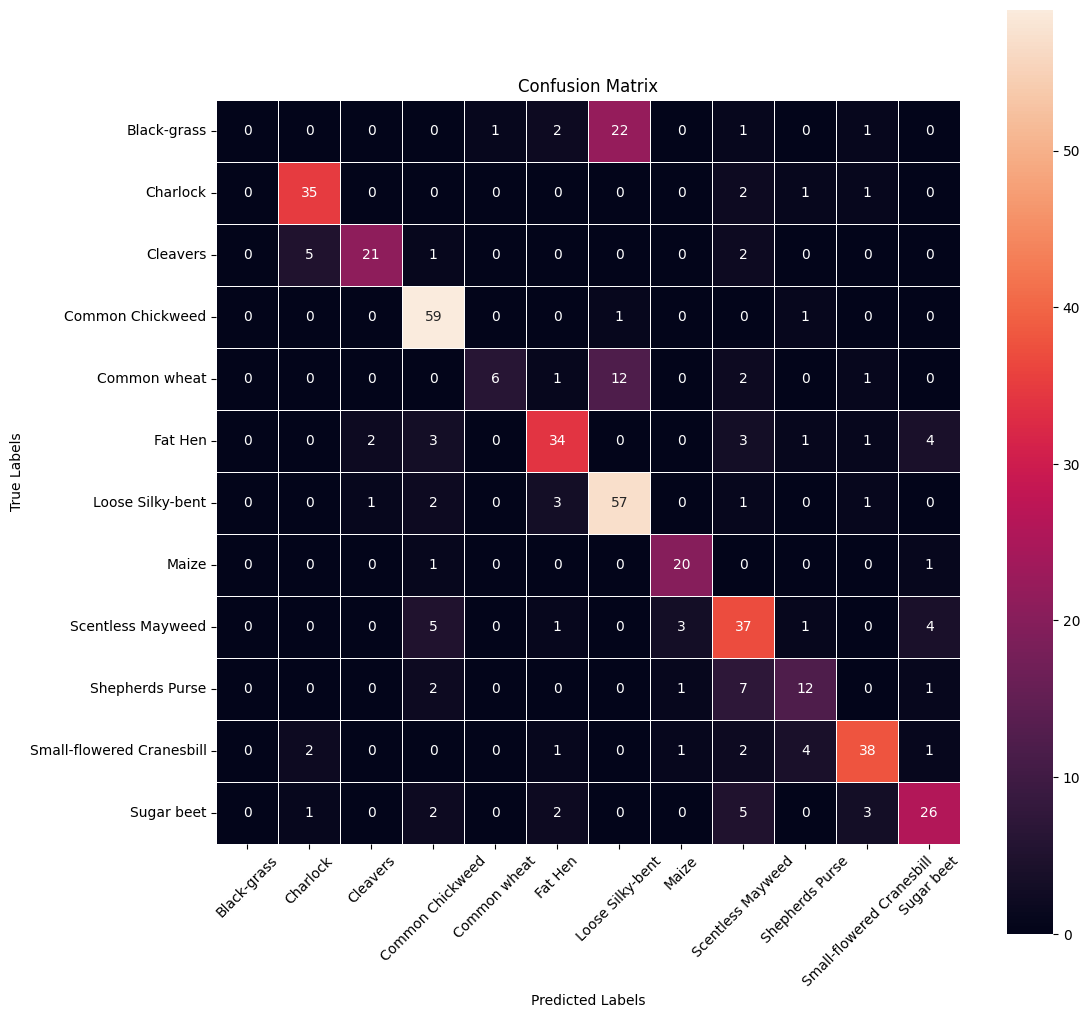

In [ ]:
plot_confusion_matrix(model1,X_val_normalized,y_val_encoded)

* The baseline CNN obtains 80.2% training accuracy and 72.6% validation accuracy. The approximately 7.5 percentage-point gap suggests moderate overfitting. Weighted F1 of 69.9% is lower than accuracy, suggesting weaker performance for some of the minority classes.

## Model Performance Improvement

**Reducing the Learning Rate:**

**Hint**: Use **ReduceLRonPlateau()** function that will be used to decrease the learning rate by some factor, if the loss is not decreasing for some time. This may start decreasing the loss at a smaller learning rate. There is a possibility that the loss may still not decrease. This may lead to executing the learning rate reduction again in an attempt to achieve a lower loss.

In [ ]:
# Code to monitor val_accuracy
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

### **Data Augmentation**

In [ ]:
# Clearing backend before defining model2
backend.clear_session()


In [ ]:
# to set the rotation_range to 20
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
# Intializing a sequential model
model2 = Sequential()

# First convolutional block
model2.add(Conv2D(128,(3, 3),activation='relu',padding='same',input_shape=(64, 64, 3)))
model2.add(MaxPooling2D((2, 2), padding='same'))

# Second convolutional block
model2.add(Conv2D(64,(3, 3),activation='relu',padding='same'))
model2.add(MaxPooling2D((2, 2), padding='same'))

# Third convolutional block
model2.add(Conv2D(32,(3, 3),activation='relu',padding='same'))
model2.add(MaxPooling2D((2, 2), padding='same'))

# Flatten the feature maps
model2.add(Flatten())

# Dense layer
model2.add(Dense(16, activation='relu'))

# Dropout to reduce overfitting
model2.add(Dropout(0.3))

# Output layer for 12 plant classes
model2.add(Dense(12, activation='softmax'))

#Compile model2
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        32,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,828 (503.23 KB)

 Trainable params: 128,828 (503.23 KB)

 Non-trainable params: 0 (0.00 B)

<b> Fitting the model on the train data

In [ ]:
# fitingt the model on train data with batch_size=32 and epochs=30
# Epochs
epochs = 30
# Batch size
batch_size = 32

history = model2.fit(train_datagen.flow(X_train_normalized,y_train_encoded,
                                       batch_size=batch_size,
                                        shuffle=True),
                                       epochs=epochs,
                                       validation_data=(X_val_normalized,y_val_encoded),
                                       verbose=1,callbacks=[learning_rate_reduction])

Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.1374 - loss: 2.4564 - val_accuracy: 0.2379 - val_loss: 2.3082 - learning_rate: 0.0010
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.2945 - loss: 2.1453 - val_accuracy: 0.3600 - val_loss: 1.8605 - learning_rate: 0.0010
Epoch 3/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.3455 - loss: 1.9370 - val_accuracy: 0.4358 - val_loss: 1.6386 - learning_rate: 0.0010
Epoch 4/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.3732 - loss: 1.7879 - val_accuracy: 0.4716 - val_loss: 1.4744 - learning_rate: 0.0010
Epoch 5/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.4134 - loss: 1.6610 - val_accuracy: 0.5305 - val_loss: 1.3656 - learning_rate: 0.0010
Epoch 6/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.4089 - loss: 1.6406 - val_accuracy: 0.5242 - val_loss: 1.2951 - learning_rate: 0.0010
Epoch 7/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.4379 - loss: 1.

**Model Evaluation**

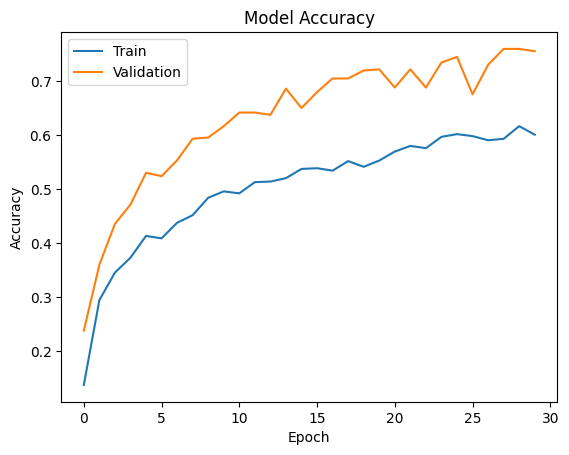

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Evaluate the model on Train data**

In [ ]:
model_2_train_perf = model_performance_classification(model2, X_train_normalized,y_train_encoded)

print("Train performance metrics")
print(model_2_train_perf)

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.758947  0.758947   0.737838  0.733018


119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


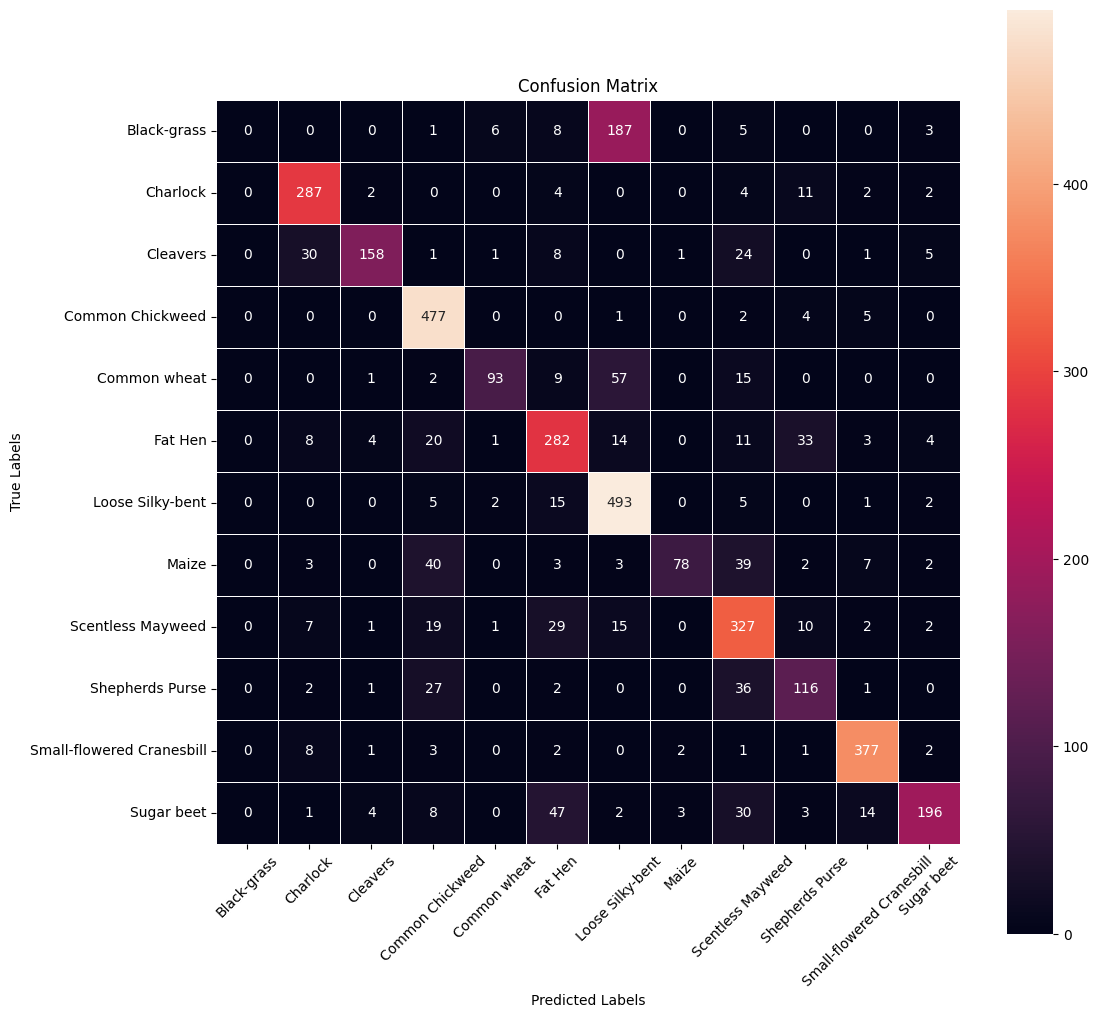

In [ ]:
# Plot the confusion matrix for Model 2 using the utility function
plot_confusion_matrix(model2, X_train_normalized, y_train_encoded)

**Evaluate the model on Validation data**

In [ ]:
model_2_valid_perf = model_performance_classification(model2, X_val_normalized,y_val_encoded)

print("Validation performance metrics")
print(model_2_valid_perf)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.755789  0.755789   0.728277  0.731639


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


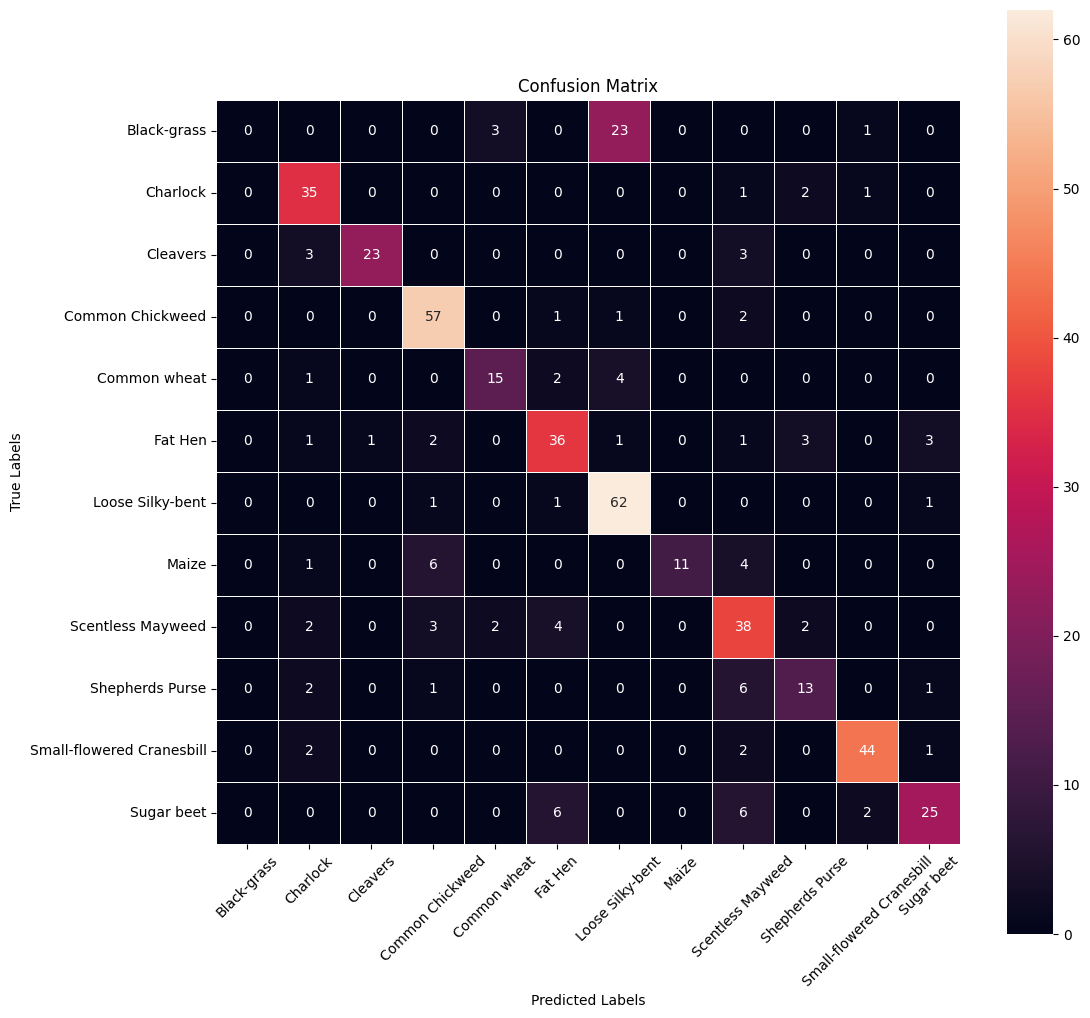

In [ ]:
# Plot the confusion matrix for Model 2 using the utility function
plot_confusion_matrix(model2, X_val_normalized, y_val_encoded)

* Model 2 achieved approximately 75.6% validation accuracy and a 73.2% weighted F1-score. It outperformed the baseline Model 1, which achieved 72.6% validation accuracy and 69.9% weighted F1-score. The improved validation performance suggests that the Model 2 configuration with data augmentation generalizes better to unseen validation data.

## **Final Model**

Comment on the final model you have selected and use the same in the below code to visualize the image.

In [ ]:
# training performance comparison
comparison = pd.DataFrame({
    'Model': ['CNN Base Model', 'CNN with Augmentation'],
    'Accuracy': [
        model_1_train_perf['Accuracy'].iloc[0],
        model_2_train_perf['Accuracy'].iloc[0]
    ],
    'Precision': [
        model_1_train_perf['Precision'].iloc[0],
        model_2_train_perf['Precision'].iloc[0]
    ],
    'Recall': [
        model_1_train_perf['Recall'].iloc[0],
        model_2_train_perf['Recall'].iloc[0]
    ],
    'F1 Score': [
        model_1_train_perf['F1 Score'].iloc[0],
        model_2_train_perf['F1 Score'].iloc[0]
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,CNN Base Model,0.801579,0.761269,0.801579,0.769829
1,CNN with Augmentation,0.758947,0.737838,0.758947,0.733018


In [ ]:
# validation performance comparison
comparison = pd.DataFrame({
    'Model': ['Model1:CNN Base Model', 'Model2:CNN with Augmentation'],
    'Accuracy': [
        model_1_valid_perf['Accuracy'].iloc[0],
        model_2_valid_perf['Accuracy'].iloc[0]
    ],
    'Precision': [
        model_1_valid_perf['Precision'].iloc[0],
        model_2_valid_perf['Precision'].iloc[0]
    ],
    'Recall': [
        model_1_valid_perf['Recall'].iloc[0],
        model_2_valid_perf['Recall'].iloc[0]
    ],
    'F1 Score': [
        model_1_valid_perf['F1 Score'].iloc[0],
        model_2_valid_perf['F1 Score'].iloc[0]
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Model1:CNN Base Model,0.726316,0.696936,0.726316,0.698574
1,Model2:CNN with Augmentation,0.755789,0.728277,0.755789,0.731639


* Model 2 achieved approximately 75.9% training accuracy and 75.6% validation accuracy, with a weighted validation F1-score of 73.2%. The very small gap between training and validation accuracy indicates substantially better generalization compared with Model 1. Model 2 also outperformed Model 1 on both validation accuracy and weighted F1-score, suggesting that the augmented training configuration helped reduce overfitting.

## Test Performance

In [ ]:
model_test_perf = model_performance_classification(model2, X_test_normalized,y_test_encoded)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [ ]:
model_test_perf

,Accuracy,Recall,Precision,F1 Score
0,0.751579,0.751579,0.734086,0.719766


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


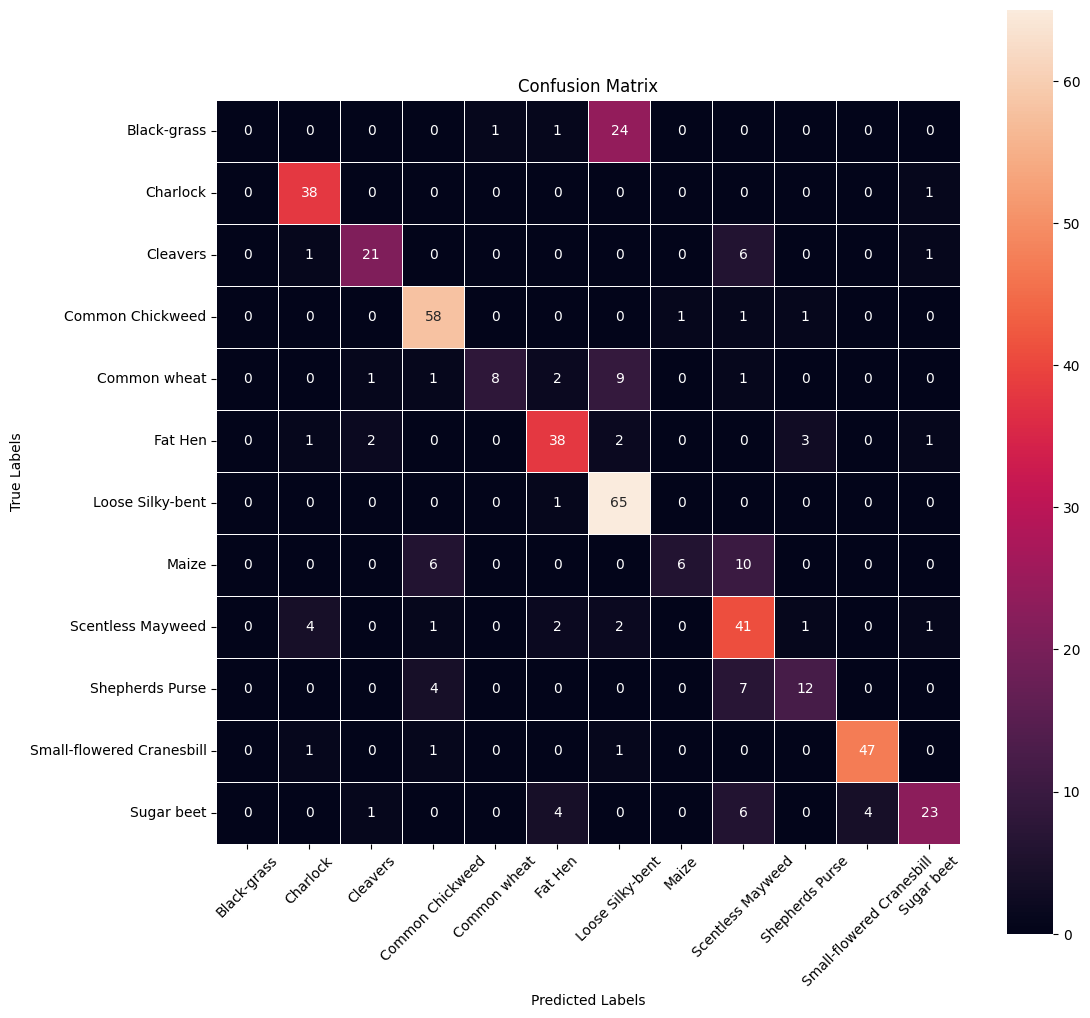

In [ ]:
plot_confusion_matrix(model2, X_test_normalized,y_test_encoded)

### Visualizing the prediction

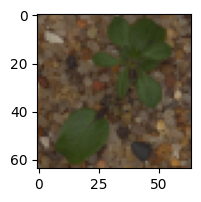

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Predicted Label ['Cleavers']
True Label Cleavers


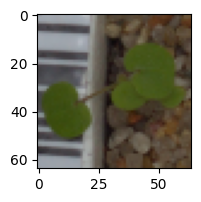

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Label ['Small-flowered Cranesbill']
True Label Small-flowered Cranesbill


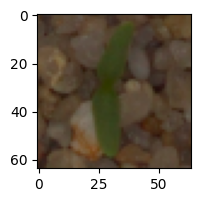

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Label ['Scentless Mayweed']
True Label Sugar beet


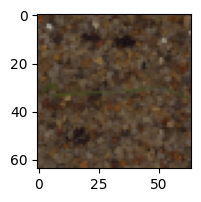

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Label ['Loose Silky-bent']
True Label Loose Silky-bent


In [ ]:
# Visualizing the predicted and correct label of images from test data

# Image 1
plt.figure(figsize=(2,2))
plt.imshow(X_test[2])
plt.show()

# Predict using the final selected model - Model 2
print('Predicted Label',
      enc.inverse_transform(
          model2.predict(X_test_normalized[2].reshape(1,64,64,3))
      ))

print('True Label',
      enc.inverse_transform(y_test_encoded)[2])


# Image 2
plt.figure(figsize=(2,2))
plt.imshow(X_test[33])
plt.show()

# Predict using the final selected model - Model 2
print('Predicted Label',
      enc.inverse_transform(
          model2.predict(X_test_normalized[33].reshape(1,64,64,3))
      ))

print('True Label',
      enc.inverse_transform(y_test_encoded)[33])


# Image 3
plt.figure(figsize=(2,2))
plt.imshow(X_test[59])
plt.show()

# Predict using the final selected model - Model 2
print('Predicted Label',
      enc.inverse_transform(
          model2.predict(X_test_normalized[59].reshape(1,64,64,3))
      ))

print('True Label',
      enc.inverse_transform(y_test_encoded)[59])


# Image 4
plt.figure(figsize=(2,2))
plt.imshow(X_test[36])
plt.show()

# Predict using the final selected model - Model 2
print('Predicted Label',
      enc.inverse_transform(
          model2.predict(X_test_normalized[36].reshape(1,64,64,3))
      ))

print('True Label',
      enc.inverse_transform(y_test_encoded)[36])

## Actionable Insights and Business Recommendations

* The dataset contains 4,750 images representing 12 plant species, with an imbalanced class distribution. This imbalance may make classification more difficult for species with fewer training samples.

* The baseline CNN (Model 1) achieved approximately 72.6% validation accuracy and a 69.9% weighted F1-score, while Model 2 with data augmentation achieved approximately 75.6% validation accuracy and a 73.2% weighted F1-score.

* Model 2 also showed almost identical training and validation accuracy, approximately 75.9% and 75.6%, respectively, indicating better generalization and less overfitting than Model 1.

* Model 2 was selected as the final model and achieved approximately 75.2% accuracy, 73.4% weighted precision, 75.2% weighted recall, and 72.0% weighted F1-score on the held-out test set. The close validation and test accuracy suggests that the model generalizes reasonably well to unseen images.

* Collecting additional images for underrepresented species and applying targeted augmentation could further improve performance on minority classes.

* An automated seedling-classification system could help farmers and agricultural workers identify crops and weeds more efficiently and support faster field-management decisions.

* Before deployment, the model should be evaluated on a larger and more diverse dataset covering different lighting conditions, backgrounds, plant orientations, growth stages, and image quality. Further improvement could include hyperparameter tuning, class weighting, targeted augmentation, and transfer learning using pretrained CNN architectures.*